# 🤖 SatEnergy — Notebook 03: Modelo de Previsão de Geração Renovável

**Objetivo:** Treinar um modelo de Machine Learning para prever o fator de capacidade de geração solar e eólica com base em variáveis temporais e geográficas.

| Etapa | Descrição |
|-------|-----------|
| 1 | Preparação e feature engineering |
| 2 | Treinamento do modelo (XGBoost) |
| 3 | Avaliação de performance |
| 4 | Importância das variáveis |
| 5 | Previsão em novos dados |

## 0. Imports e Configuração

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import glob
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 1. Carregando e Preparando os Dados

In [2]:
# Carregando dados ONS
arquivos = glob.glob("../data/raw/FATOR*.csv")
df = pd.read_csv(arquivos[0], sep=";", encoding="utf-8")
df["din_instante"] = pd.to_datetime(df["din_instante"])

print(f"✅ {len(df):,} registros carregados")
print(f"Tipos de usina: {df['nom_tipousina'].unique()}")

✅ 166,320 registros carregados
Tipos de usina: <ArrowStringArray>
['Eólica', 'Solar']
Length: 2, dtype: str


## 2. Feature Engineering

Criando variáveis derivadas do tempo e da localização para alimentar o modelo.

In [3]:
def criar_features(df):
    df = df.copy()
    
    # Features temporais
    df["hora"]          = df["din_instante"].dt.hour
    df["mes"]           = df["din_instante"].dt.month
    df["dia_semana"]    = df["din_instante"].dt.dayofweek
    df["dia_ano"]       = df["din_instante"].dt.dayofyear
    df["trimestre"]     = df["din_instante"].dt.quarter

    # Features cíclicas (seno/cosseno para capturar ciclicidade)
    df["hora_sin"]      = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"]      = np.cos(2 * np.pi * df["hora"] / 24)
    df["mes_sin"]       = np.sin(2 * np.pi * df["mes"] / 12)
    df["mes_cos"]       = np.cos(2 * np.pi * df["mes"] / 12)
    df["dia_ano_sin"]   = np.sin(2 * np.pi * df["dia_ano"] / 365)
    df["dia_ano_cos"]   = np.cos(2 * np.pi * df["dia_ano"] / 365)

    # Features geográficas
    df["latitude"]      = df["val_latitudesecoletora"]
    df["longitude"]     = df["val_longitudesecoletora"]
    df["capacidade"]    = df["val_capacidadeinstalada"]

    # Encoding de variáveis categóricas
    le_sub = LabelEncoder()
    le_estado = LabelEncoder()
    df["subsistema_enc"] = le_sub.fit_transform(df["nom_subsistema"].astype(str))
    df["estado_enc"]     = le_estado.fit_transform(df["nom_estado"].astype(str))

    return df

df = criar_features(df)
print(f"✅ Features criadas: {df.shape[1]} colunas")

✅ Features criadas: 37 colunas


## 3. Modelo Solar — Previsão do Fator de Capacidade

In [4]:
# Filtrando usinas solares
df_solar = df[df["nom_tipousina"] == "Solar"].dropna(subset=["val_fatorcapacidade"]).copy()

FEATURES = [
    "hora", "mes", "dia_semana", "trimestre",
    "hora_sin", "hora_cos", "mes_sin", "mes_cos", "dia_ano_sin", "dia_ano_cos",
    "latitude", "longitude", "capacidade",
    "subsistema_enc", "estado_enc"
]

X = df_solar[FEATURES].fillna(0)
y = df_solar["val_fatorcapacidade"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dataset solar preparado")
print(f"   Treino: {len(X_train):,} registros")
print(f"   Teste:  {len(X_test):,} registros")

✅ Dataset solar preparado
   Treino: 44,928 registros
   Teste:  11,232 registros


In [5]:
# Treinando modelo XGBoost Solar
print("⏳ Treinando modelo solar...")

modelo_solar = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_solar.fit(X_train, y_train)

y_pred_solar = modelo_solar.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_solar)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_solar))
r2   = r2_score(y_test, y_pred_solar)

print(f"\n📊 Performance — Modelo Solar:")
print(f"   MAE:  {mae:.4f}  (erro médio absoluto)")
print(f"   RMSE: {rmse:.4f} (raiz do erro quadrático)")
print(f"   R²:   {r2:.4f}  (coeficiente de determinação)")

# Salvando modelo
joblib.dump(modelo_solar, "../models/modelo_solar.pkl")
print("\n✅ Modelo solar salvo em models/modelo_solar.pkl")

⏳ Treinando modelo solar...

📊 Performance — Modelo Solar:
   MAE:  0.0534  (erro médio absoluto)
   RMSE: 0.0953 (raiz do erro quadrático)
   R²:   0.8718  (coeficiente de determinação)

✅ Modelo solar salvo em models/modelo_solar.pkl


## 4. Modelo Eólico — Previsão do Fator de Capacidade

In [6]:
# Filtrando usinas eólicas
df_eolica = df[df["nom_tipousina"] == "Eólica"].dropna(subset=["val_fatorcapacidade"]).copy()

X_e = df_eolica[FEATURES].fillna(0)
y_e = df_eolica["val_fatorcapacidade"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

print("⏳ Treinando modelo eólico...")

modelo_eolico = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_eolico.fit(X_train_e, y_train_e)
y_pred_eolico = modelo_eolico.predict(X_test_e)

mae_e  = mean_absolute_error(y_test_e, y_pred_eolico)
rmse_e = np.sqrt(mean_squared_error(y_test_e, y_pred_eolico))
r2_e   = r2_score(y_test_e, y_pred_eolico)

print(f"\n📊 Performance — Modelo Eólico:")
print(f"   MAE:  {mae_e:.4f}  (erro médio absoluto)")
print(f"   RMSE: {rmse_e:.4f} (raiz do erro quadrático)")
print(f"   R²:   {r2_e:.4f}  (coeficiente de determinação)")

joblib.dump(modelo_eolico, "../models/modelo_eolico.pkl")
print("\n✅ Modelo eólico salvo em models/modelo_eolico.pkl")

⏳ Treinando modelo eólico...

📊 Performance — Modelo Eólico:
   MAE:  0.0969  (erro médio absoluto)
   RMSE: 0.1334 (raiz do erro quadrático)
   R²:   0.7255  (coeficiente de determinação)

✅ Modelo eólico salvo em models/modelo_eolico.pkl


## 5. Avaliação Visual — Previsto vs Real

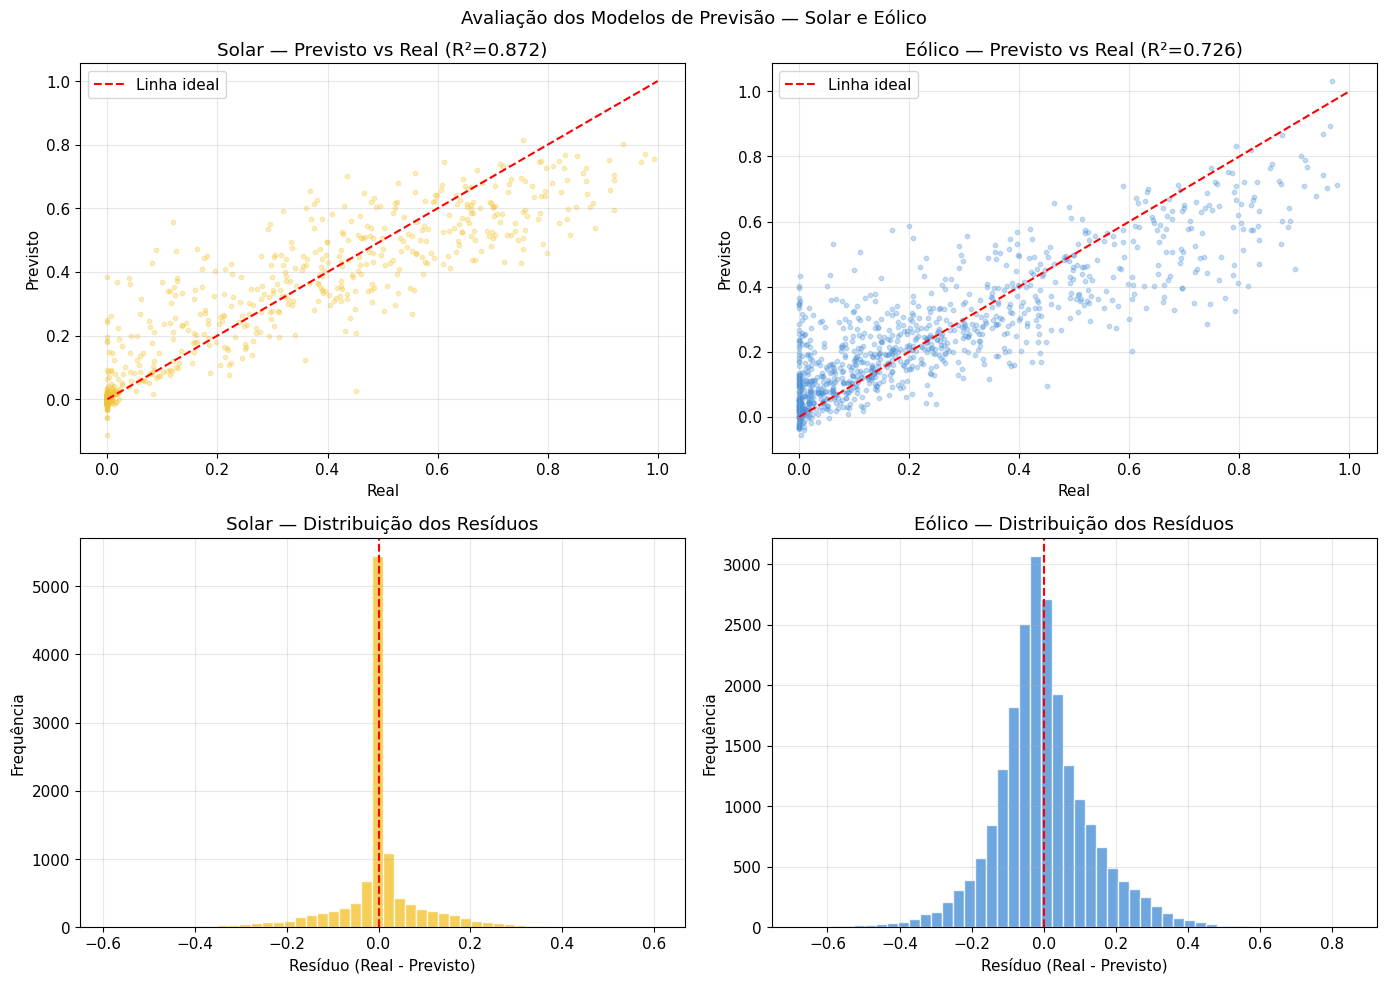

✅ Gráfico de avaliação salvo


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Solar — Previsto vs Real (scatter)
axes[0,0].scatter(y_test[:1000], y_pred_solar[:1000], alpha=0.3, color="#f4c430", s=10)
axes[0,0].plot([0,1], [0,1], "r--", linewidth=1.5, label="Linha ideal")
axes[0,0].set_title(f"Solar — Previsto vs Real (R²={r2:.3f})")
axes[0,0].set_xlabel("Real")
axes[0,0].set_ylabel("Previsto")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Eólico — Previsto vs Real (scatter)
axes[0,1].scatter(y_test_e[:1000], y_pred_eolico[:1000], alpha=0.3, color="#4a90d9", s=10)
axes[0,1].plot([0,1], [0,1], "r--", linewidth=1.5, label="Linha ideal")
axes[0,1].set_title(f"Eólico — Previsto vs Real (R²={r2_e:.3f})")
axes[0,1].set_xlabel("Real")
axes[0,1].set_ylabel("Previsto")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Solar — Resíduos
residuos_s = y_test.values - y_pred_solar
axes[1,0].hist(residuos_s, bins=50, color="#f4c430", edgecolor="white", alpha=0.8)
axes[1,0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1,0].set_title("Solar — Distribuição dos Resíduos")
axes[1,0].set_xlabel("Resíduo (Real - Previsto)")
axes[1,0].set_ylabel("Frequência")
axes[1,0].grid(True, alpha=0.3)

# Eólico — Resíduos
residuos_e = y_test_e.values - y_pred_eolico
axes[1,1].hist(residuos_e, bins=50, color="#4a90d9", edgecolor="white", alpha=0.8)
axes[1,1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1,1].set_title("Eólico — Distribuição dos Resíduos")
axes[1,1].set_xlabel("Resíduo (Real - Previsto)")
axes[1,1].set_ylabel("Frequência")
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Avaliação dos Modelos de Previsão — Solar e Eólico", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/modelo_avaliacao.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico de avaliação salvo")

## 6. Importância das Variáveis

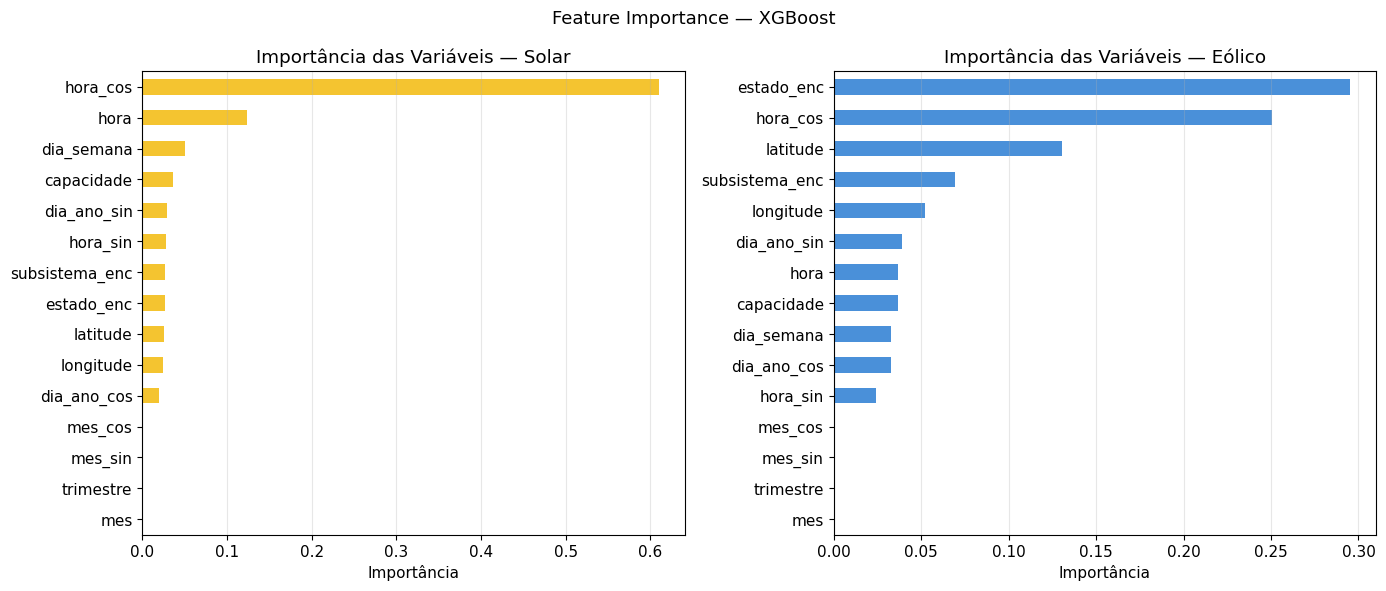

✅ Gráfico de importância salvo


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Solar
imp_solar = pd.Series(modelo_solar.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp_solar.plot(kind="barh", ax=axes[0], color="#f4c430")
axes[0].set_title("Importância das Variáveis — Solar")
axes[0].set_xlabel("Importância")
axes[0].grid(True, alpha=0.3, axis="x")

# Eólico
imp_eolico = pd.Series(modelo_eolico.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp_eolico.plot(kind="barh", ax=axes[1], color="#4a90d9")
axes[1].set_title("Importância das Variáveis — Eólico")
axes[1].set_xlabel("Importância")
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle("Feature Importance — XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/modelo_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico de importância salvo")

## 7. Resumo dos Modelos

In [9]:
print("=" * 60)
print("🤖 RESUMO DOS MODELOS — SATENERGY")
print("=" * 60)

print(f"""
🌞 MODELO SOLAR (XGBoost)
   Registros de treino: {len(X_train):,}
   MAE:  {mae:.4f}
   RMSE: {rmse:.4f}
   R²:   {r2:.4f}
   Variável mais importante: {imp_solar.idxmax()}

💨 MODELO EÓLICO (XGBoost)
   Registros de treino: {len(X_train_e):,}
   MAE:  {mae_e:.4f}
   RMSE: {rmse_e:.4f}
   R²:   {r2_e:.4f}
   Variável mais importante: {imp_eolico.idxmax()}

💾 Modelos salvos em:
   models/modelo_solar.pkl
   models/modelo_eolico.pkl
""")
print("✅ Modelos prontos para uso no dashboard!")
print("=" * 60)

🤖 RESUMO DOS MODELOS — SATENERGY

🌞 MODELO SOLAR (XGBoost)
   Registros de treino: 44,928
   MAE:  0.0534
   RMSE: 0.0953
   R²:   0.8718
   Variável mais importante: hora_cos

💨 MODELO EÓLICO (XGBoost)
   Registros de treino: 88,128
   MAE:  0.0969
   RMSE: 0.1334
   R²:   0.7255
   Variável mais importante: estado_enc

💾 Modelos salvos em:
   models/modelo_solar.pkl
   models/modelo_eolico.pkl

✅ Modelos prontos para uso no dashboard!


---------------------------------------------------------------------------------------------------------------------------------------------

In [11]:
import requests

# NASA POWER API — Dados de irradiância solar
lat, lon = -8.0, -45.0

url = (
    f"https://power.larc.nasa.gov/api/temporal/hourly/point?"
    f"parameters=ALLSKY_SFC_SW_DWN,T2M,WS10M,CLOUD_AMT"
    f"&community=RE"
    f"&longitude={lon}&latitude={lat}"
    f"&start=20260401&end=20260430"
    f"&format=JSON"
)

print("🛰️ Conectando à NASA POWER API...")
r = requests.get(url, timeout=60)
print(f"Status: {r.status_code}")

if r.status_code == 200:
    dados = r.json()
    print("✅ Conectado!")
    print(f"Parâmetros disponíveis: {list(dados['properties']['parameter'].keys())}")
else:
    print(f"Erro: {r.text[:200]}")

🛰️ Conectando à NASA POWER API...
Status: 200
✅ Conectado!
Parâmetros disponíveis: ['ALLSKY_SFC_SW_DWN', 'T2M', 'WS10M', 'CLOUD_AMT']


In [12]:
# Baixando dados climáticos da NASA para as principais regiões do Brasil
regioes = {
    "Nordeste":           (-8.0,  -40.0),
    "Sudeste":            (-20.0, -45.0),
    "Sul":                (-28.0, -52.0),
    "Norte":              (-5.0,  -60.0),
    "Centro-Oeste":       (-15.0, -55.0),
}

dfs_nasa = []

for regiao, (lat, lon) in regioes.items():
    print(f"⏳ Baixando {regiao}...")
    url = (
        f"https://power.larc.nasa.gov/api/temporal/hourly/point?"
        f"parameters=ALLSKY_SFC_SW_DWN,T2M,WS10M,CLOUD_AMT"
        f"&community=RE"
        f"&longitude={lon}&latitude={lat}"
        f"&start=20260401&end=20260430"
        f"&format=JSON"
    )
    r = requests.get(url, timeout=60)
    if r.status_code == 200:
        dados = r.json()
        params = dados["properties"]["parameter"]

        # Convertendo para DataFrame
        df_temp = pd.DataFrame(params)
        df_temp.index = pd.to_datetime(df_temp.index, format="%Y%m%d%H")
        df_temp.index.name = "din_instante"
        df_temp = df_temp.reset_index()
        df_temp["regiao"]    = regiao
        df_temp["latitude"]  = lat
        df_temp["longitude"] = lon
        df_temp.columns = ["din_instante", "irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct", "regiao", "latitude", "longitude"]
        dfs_nasa.append(df_temp)
        print(f"  ✅ {len(df_temp)} registros")

df_nasa = pd.concat(dfs_nasa, ignore_index=True)
print(f"\n✅ Total: {len(df_nasa):,} registros NASA POWER carregados!")
print(df_nasa.head())

⏳ Baixando Nordeste...
  ✅ 720 registros
⏳ Baixando Sudeste...
  ✅ 720 registros
⏳ Baixando Sul...
  ✅ 720 registros
⏳ Baixando Norte...
  ✅ 720 registros
⏳ Baixando Centro-Oeste...
  ✅ 720 registros

✅ Total: 3,600 registros NASA POWER carregados!
         din_instante  irradiancia_wm2  temperatura_c  vento_ms  nuvens_pct  \
0 2026-04-01 00:00:00           -999.0          22.51      3.42      -999.0   
1 2026-04-01 01:00:00           -999.0          22.00      3.60      -999.0   
2 2026-04-01 02:00:00           -999.0          21.53      3.02      -999.0   
3 2026-04-01 03:00:00           -999.0          21.33      2.74      -999.0   
4 2026-04-01 04:00:00           -999.0          21.31      2.68      -999.0   

     regiao  latitude  longitude  
0  Nordeste      -8.0      -40.0  
1  Nordeste      -8.0      -40.0  
2  Nordeste      -8.0      -40.0  
3  Nordeste      -8.0      -40.0  
4  Nordeste      -8.0      -40.0  


In [13]:
# Limpando valores nulos (-999 é o padrão NASA para dados ausentes)
df_nasa["irradiancia_wm2"] = df_nasa["irradiancia_wm2"].replace(-999.0, np.nan)
df_nasa["nuvens_pct"]      = df_nasa["nuvens_pct"].replace(-999.0, np.nan)

# Irradiância zero à noite é correto — só substitui os -999
df_nasa["hora"] = df_nasa["din_instante"].dt.hour
df_nasa["mes"]  = df_nasa["din_instante"].dt.month

print("📊 Estatísticas dos dados NASA:")
print(df_nasa[["irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct"]].describe().round(2))

# Salvando
df_nasa.to_csv("../data/processed/nasa_power_climatico.csv", index=False)
print(f"\n✅ Dados NASA salvos em data/processed/nasa_power_climatico.csv")

📊 Estatísticas dos dados NASA:
       irradiancia_wm2  temperatura_c  vento_ms  nuvens_pct
count              0.0        3600.00   3600.00         0.0
mean               NaN          23.94      2.29         NaN
std                NaN           4.78      1.36         NaN
min                NaN           2.30      0.03         NaN
25%                NaN          21.05      1.25         NaN
50%                NaN          24.36      2.08         NaN
75%                NaN          27.34      3.09         NaN
max                NaN          34.93      6.87         NaN

✅ Dados NASA salvos em data/processed/nasa_power_climatico.csv


In [14]:
# Tentando período com dados garantidos — 2024
regioes = {
    "Nordeste":     (-8.0,  -40.0),
    "Sudeste":      (-20.0, -45.0),
    "Sul":          (-28.0, -52.0),
    "Norte":        (-5.0,  -60.0),
    "Centro-Oeste": (-15.0, -55.0),
}

dfs_nasa = []

for regiao, (lat, lon) in regioes.items():
    print(f"⏳ Baixando {regiao}...")
    url = (
        f"https://power.larc.nasa.gov/api/temporal/hourly/point?"
        f"parameters=ALLSKY_SFC_SW_DWN,T2M,WS10M,CLOUD_AMT"
        f"&community=RE"
        f"&longitude={lon}&latitude={lat}"
        f"&start=20240101&end=20240131"
        f"&format=JSON"
    )
    r = requests.get(url, timeout=60)
    if r.status_code == 200:
        dados = r.json()
        params = dados["properties"]["parameter"]
        df_temp = pd.DataFrame(params)
        df_temp.index = pd.to_datetime(df_temp.index, format="%Y%m%d%H")
        df_temp.index.name = "din_instante"
        df_temp = df_temp.reset_index()
        df_temp["regiao"]    = regiao
        df_temp["latitude"]  = lat
        df_temp["longitude"] = lon
        df_temp.columns = ["din_instante", "irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct", "regiao", "latitude", "longitude"]
        df_temp["irradiancia_wm2"] = df_temp["irradiancia_wm2"].replace(-999.0, np.nan)
        df_temp["nuvens_pct"]      = df_temp["nuvens_pct"].replace(-999.0, np.nan)
        dfs_nasa.append(df_temp)
        print(f"  ✅ {len(df_temp)} registros")

df_nasa = pd.concat(dfs_nasa, ignore_index=True)
print(f"\n✅ Total: {len(df_nasa):,} registros")
print(df_nasa[["irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct"]].describe().round(2))

⏳ Baixando Nordeste...
  ✅ 744 registros
⏳ Baixando Sudeste...
  ✅ 744 registros
⏳ Baixando Sul...
  ✅ 744 registros
⏳ Baixando Norte...
  ✅ 744 registros
⏳ Baixando Centro-Oeste...
  ✅ 744 registros

✅ Total: 3,720 registros
       irradiancia_wm2  temperatura_c  vento_ms  nuvens_pct
count          3720.00        3720.00   3720.00     3720.00
mean            235.81          25.72      2.08       73.02
std             307.32           4.23      1.16       31.43
min               0.00          12.54      0.05        0.36
25%               0.00          22.87      1.20       48.92
50%              35.72          25.64      1.93       89.08
75%             463.11          28.54      2.74       99.37
max            1067.10          38.49      6.34      100.00


✅ Dados NASA salvos!


<Axes: xlabel='regiao'>

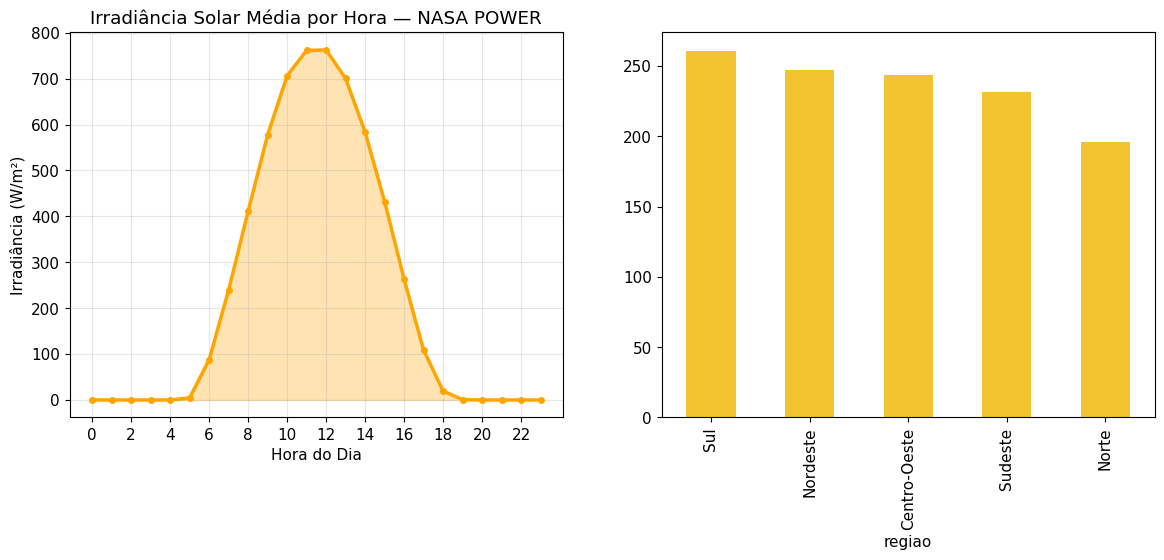

In [16]:
# Salvando dados NASA com período correto
df_nasa["hora"] = df_nasa["din_instante"].dt.hour
df_nasa["mes"]  = df_nasa["din_instante"].dt.month

df_nasa.to_csv("../data/processed/nasa_power_climatico.csv", index=False)
print("✅ Dados NASA salvos!")

# Visualizando irradiância média por hora e região
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Irradiância por hora
nasa_hora = df_nasa.groupby("hora")["irradiancia_wm2"].mean()
axes[0].plot(nasa_hora.index, nasa_hora.values, color="orange", linewidth=2.5, marker="o", markersize=4)
axes[0].fill_between(nasa_hora.index, nasa_hora.values, alpha=0.3, color="orange")
axes[0].set_title("Irradiância Solar Média por Hora — NASA POWER")
axes[0].set_xlabel("Hora do Dia")
axes[0].set_ylabel("Irradiância (W/m²)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Irradiância por região
nasa_regiao = df_nasa.groupby("regiao")["irradiancia_wm2"].mean().sort_values(ascending=False)
nasa_regiao.plot(kind="bar", ax=axes[1], color="#f4c430")

In [19]:
# Incorporando dados NASA como features no modelo
# Cruzando por região e hora

# Média das variáveis climáticas por região e hora
nasa_features = df_nasa.groupby(["regiao", "hora"])[["irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct"]].mean().reset_index()

# Mapeando regiões ONS para regiões NASA
mapa_regioes = {
    "Nordeste":            "Nordeste",
    "Sudeste/Centro-Oeste": "Sudeste",
    "Sul":                 "Sul",
    "Norte":               "Norte",
}

df_solar["regiao_nasa"] = df_solar["nom_subsistema"].map(mapa_regioes).fillna("Centro-Oeste")
df_eolica["regiao_nasa"] = df_eolica["nom_subsistema"].map(mapa_regioes).fillna("Centro-Oeste")

# Merge com dados NASA
df_solar = df_solar.merge(nasa_features, left_on=["regiao_nasa", "hora"], right_on=["regiao", "hora"], how="left")
df_eolica = df_eolica.merge(nasa_features, left_on=["regiao_nasa", "hora"], right_on=["regiao", "hora"], how="left")

print(f"✅ Features NASA incorporadas!")
print(f"Solar:  {df_solar.shape}")
print(f"Eólica: {df_eolica.shape}")
print(f"\nNovos campos: irradiancia_wm2, temperatura_c, vento_ms, nuvens_pct")

✅ Features NASA incorporadas!
Solar:  (56160, 48)
Eólica: (110160, 48)

Novos campos: irradiancia_wm2, temperatura_c, vento_ms, nuvens_pct


In [20]:
# Retreinando modelos com features NASA
FEATURES_NASA = [
    "hora", "mes", "dia_semana", "trimestre",
    "hora_sin", "hora_cos", "mes_sin", "mes_cos", "dia_ano_sin", "dia_ano_cos",
    "latitude", "longitude", "capacidade",
    "subsistema_enc", "estado_enc",
    "irradiancia_wm2", "temperatura_c", "vento_ms", "nuvens_pct"
]

# Solar com NASA
X_s = df_solar[FEATURES_NASA].fillna(0)
y_s = df_solar["val_fatorcapacidade"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

print("⏳ Retreinando modelo solar com features NASA...")
modelo_solar_nasa = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
modelo_solar_nasa.fit(X_train_s, y_train_s)
y_pred_s = modelo_solar_nasa.predict(X_test_s)

mae_s2  = mean_absolute_error(y_test_s, y_pred_s)
rmse_s2 = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s2   = r2_score(y_test_s, y_pred_s)

# Eólico com NASA
X_e2 = df_eolica[FEATURES_NASA].fillna(0)
y_e2 = df_eolica["val_fatorcapacidade"]
X_train_e2, X_test_e2, y_train_e2, y_test_e2 = train_test_split(X_e2, y_e2, test_size=0.2, random_state=42)

print("⏳ Retreinando modelo eólico com features NASA...")
modelo_eolico_nasa = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
modelo_eolico_nasa.fit(X_train_e2, y_train_e2)
y_pred_e2 = modelo_eolico_nasa.predict(X_test_e2)

mae_e2  = mean_absolute_error(y_test_e2, y_pred_e2)
rmse_e2 = np.sqrt(mean_squared_error(y_test_e2, y_pred_e2))
r2_e2   = r2_score(y_test_e2, y_pred_e2)

# Comparativo
print("\n" + "=" * 60)
print("📊 COMPARATIVO — SEM vs COM dados NASA")
print("=" * 60)
print(f"\n🌞 SOLAR:")
print(f"   Sem NASA → R²: {r2:.4f} | MAE: {mae:.4f}")
print(f"   Com NASA → R²: {r2_s2:.4f} | MAE: {mae_s2:.4f}")
print(f"   Melhoria R²: {((r2_s2 - r2) / r2 * 100):+.1f}%")

print(f"\n💨 EÓLICO:")
print(f"   Sem NASA → R²: {r2_e:.4f} | MAE: {mae_e:.4f}")
print(f"   Com NASA → R²: {r2_e2:.4f} | MAE: {mae_e2:.4f}")
print(f"   Melhoria R²: {((r2_e2 - r2_e) / r2_e * 100):+.1f}%")

# Salvando modelos melhorados
joblib.dump(modelo_solar_nasa,  "../models/modelo_solar.pkl")
joblib.dump(modelo_eolico_nasa, "../models/modelo_eolico.pkl")
print("\n✅ Modelos atualizados salvos!")

KeyError: "['irradiancia_wm2', 'temperatura_c', 'vento_ms', 'nuvens_pct'] not in index"

In [21]:
# Verificando colunas disponíveis
print([c for c in df_solar.columns if any(x in c for x in ["irrad", "temp", "vento", "nuv"])])

['irradiancia_wm2_x', 'temperatura_c_x', 'vento_ms_x', 'nuvens_pct_x', 'irradiancia_wm2_y', 'temperatura_c_y', 'vento_ms_y', 'nuvens_pct_y']


In [22]:
# Usando colunas _y diretamente na lista de features
FEATURES_NASA = [
    "hora", "mes", "dia_semana", "trimestre",
    "hora_sin", "hora_cos", "mes_sin", "mes_cos", "dia_ano_sin", "dia_ano_cos",
    "latitude", "longitude", "capacidade",
    "subsistema_enc", "estado_enc",
    "irradiancia_wm2_y", "temperatura_c_y", "vento_ms_y", "nuvens_pct_y"
]

print("✅ Features NASA prontas!")
print(f"Total de features: {len(FEATURES_NASA)}")

✅ Features NASA prontas!
Total de features: 19


In [24]:
# Solar com NASA
X_s = df_solar[FEATURES_NASA].fillna(0)
y_s = df_solar["val_fatorcapacidade"]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

print("⏳ Retreinando modelo solar com features NASA...")
modelo_solar_nasa = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
modelo_solar_nasa.fit(X_train_s, y_train_s)
y_pred_s = modelo_solar_nasa.predict(X_test_s)

mae_s2  = mean_absolute_error(y_test_s, y_pred_s)
rmse_s2 = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s2   = r2_score(y_test_s, y_pred_s)

# Eólico com NASA
X_e2 = df_eolica[FEATURES_NASA].fillna(0)
y_e2 = df_eolica["val_fatorcapacidade"]
X_train_e2, X_test_e2, y_train_e2, y_test_e2 = train_test_split(X_e2, y_e2, test_size=0.2, random_state=42)

print("⏳ Retreinando modelo eólico com features NASA...")
modelo_eolico_nasa = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
modelo_eolico_nasa.fit(X_train_e2, y_train_e2)
y_pred_e2 = modelo_eolico_nasa.predict(X_test_e2)

mae_e2  = mean_absolute_error(y_test_e2, y_pred_e2)
rmse_e2 = np.sqrt(mean_squared_error(y_test_e2, y_pred_e2))
r2_e2   = r2_score(y_test_e2, y_pred_e2)

# Comparativo
print("\n" + "=" * 60)
print("📊 COMPARATIVO — SEM vs COM dados NASA")
print("=" * 60)
print(f"\n🌞 SOLAR:")
print(f"   Sem NASA → R²: {r2:.4f} | MAE: {mae:.4f}")
print(f"   Com NASA → R²: {r2_s2:.4f} | MAE: {mae_s2:.4f}")
print(f"   Melhoria R²: {((r2_s2 - r2) / r2 * 100):+.1f}%")

print(f"\n💨 EÓLICO:")
print(f"   Sem NASA → R²: {r2_e:.4f} | MAE: {mae_e:.4f}")
print(f"   Com NASA → R²: {r2_e2:.4f} | MAE: {mae_e2:.4f}")
print(f"   Melhoria R²: {((r2_e2 - r2_e) / r2_e * 100):+.1f}%")

# Salvando modelos melhorados
joblib.dump(modelo_solar_nasa,  "../models/modelo_solar.pkl")
joblib.dump(modelo_eolico_nasa, "../models/modelo_eolico.pkl")
print("\n✅ Modelos atualizados salvos!")

⏳ Retreinando modelo solar com features NASA...
⏳ Retreinando modelo eólico com features NASA...

📊 COMPARATIVO — SEM vs COM dados NASA

🌞 SOLAR:
   Sem NASA → R²: 0.8718 | MAE: 0.0534
   Com NASA → R²: 0.8804 | MAE: 0.0498
   Melhoria R²: +1.0%

💨 EÓLICO:
   Sem NASA → R²: 0.7255 | MAE: 0.0969
   Com NASA → R²: 0.7237 | MAE: 0.0973
   Melhoria R²: -0.3%

✅ Modelos atualizados salvos!
